##  🌍 Co² Cleaning Data 

1- import libraries 📖

In [154]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
# Show all rows (without "..." in the middle)
pd.set_option('display.max_rows', None)

# Show all columns (without truncation)
pd.set_option('display.max_columns', None)

# Show full content of each cell (without truncation)
pd.set_option('display.max_colwidth', None)

# Show full display width (without wrapping)
pd.set_option('display.width', None)

2 - load data 📊

In [155]:
co2_data = pd.read_csv('owid-co2-data.csv')
co2_data.info()
co2_data.shape

<class 'pandas.DataFrame'>
RangeIndex: 50411 entries, 0 to 50410
Data columns (total 79 columns):
 #   Column                                     Non-Null Count  Dtype  
---  ------                                     --------------  -----  
 0   country                                    50411 non-null  str    
 1   year                                       50411 non-null  int64  
 2   iso_code                                   42480 non-null  str    
 3   population                                 41167 non-null  float64
 4   gdp                                        15251 non-null  float64
 5   cement_co2                                 29173 non-null  float64
 6   cement_co2_per_capita                      25648 non-null  float64
 7   co2                                        29384 non-null  float64
 8   co2_growth_abs                             27216 non-null  float64
 9   co2_growth_prct                            26239 non-null  float64
 10  co2_including_luc                

(50411, 79)

3 - preparing our data by remove columns we dont need in our project *➜]*

In [156]:
columns_to_keep = [
    # identifiers
    "country",
    "year",
    "iso_code",

    # target variables
    "temperature_change_from_ghg",
    "temperature_change_from_ch4",
    "total_ghg",

    # waste-related features
    "methane",
    "methane_per_capita",
    "nitrous_oxide",
    "nitrous_oxide_per_capita",
    "other_industry_co2",
    "other_co2_per_capita",
    "land_use_change_co2",

    # economic & population features
    "population",
    "gdp",
    "consumption_co2_per_capita",
    "co2_per_gdp",
    "energy_per_capita",
    "co2_per_capita",
    "ghg_per_capita",
    "share_of_temperature_change_from_ghg",
]

co2_data = co2_data[columns_to_keep]
print("Columns in the filtered dataset:")
print(co2_data.columns)
print(co2_data.shape)

Columns in the filtered dataset:
Index(['country', 'year', 'iso_code', 'temperature_change_from_ghg',
       'temperature_change_from_ch4', 'total_ghg', 'methane',
       'methane_per_capita', 'nitrous_oxide', 'nitrous_oxide_per_capita',
       'other_industry_co2', 'other_co2_per_capita', 'land_use_change_co2',
       'population', 'gdp', 'consumption_co2_per_capita', 'co2_per_gdp',
       'energy_per_capita', 'co2_per_capita', 'ghg_per_capita',
       'share_of_temperature_change_from_ghg'],
      dtype='str')
(50411, 21)


We selected these columns because they directly represent the mechanisms through which waste and poor waste management contribute to global warming. Methane and nitrous oxide are the core waste-related gases, as landfills are the leading global source of methane while wastewater treatment releases nitrous oxide. Other industry CO2 captures emissions from waste incineration and recycling operations, and land use change CO2 reflects land degradation tied to improper disposal. The temperature change columns serve as our target variables since they directly measure the warming impact caused by these gases. Economic and population features like GDP, population, and consumption-based CO2 are included because waste generation is fundamentally driven by how many people there are and how much they consume. All remaining columns — fossil fuel sources, cumulative totals, and global share columns — were dropped because they either describe energy production unrelated to waste, or are redundant derivatives of the columns we already kept.

4 -  Now let's choose the useful rows from the remaining rows.🔎

In [157]:
co2_data = co2_data[co2_data['year'] >= 1990]
print(f"Dataset filtered to years >= 1990. Remaining rows: {co2_data.shape[0]}")
print(f"Year range: {co2_data['year'].min()} - {co2_data['year'].max()}")
print(f"Dataset shape: {co2_data.shape}")
print(f"Null values:\n{co2_data.isna().sum()}")
co2_data.to_csv('owid-co2-with-nulls.csv', index=False)

Dataset filtered to years >= 1990. Remaining rows: 8883
Year range: 1990 - 2024
Dataset shape: (8883, 21)
Null values:
country                                    0
year                                       0
iso_code                                1253
temperature_change_from_ghg              588
temperature_change_from_ch4             1183
total_ghg                               1253
methane                                 1253
methane_per_capita                      1498
nitrous_oxide                           1183
nitrous_oxide_per_capita                1428
other_industry_co2                      6713
other_co2_per_capita                    6783
land_use_change_co2                     1393
population                               868
gdp                                     3462
consumption_co2_per_capita              4240
co2_per_gdp                             2935
energy_per_capita                       1523
co2_per_capita                           815
ghg_per_capita            

We started the analysis from 1990 because most of the key columns in this dataset, such as methane, nitrous oxide, and temperature change, only began to be recorded consistently around that period. Rows before 1990 contain a high percentage of missing values, particularly for developing countries, which would either force excessive imputation or significantly reduce the reliability of the model. Starting from 1990 gives us cleaner, more complete data while still covering over three decades of observations, which is sufficient for meaningful analysis and modeling.

5 - is every useful column can we use in our analysis ? 🧐

In [158]:
threshold = 0.5
cols_before = set(co2_data.columns)
co2_data = co2_data.dropna(thresh=int(threshold * len(co2_data)), axis=1)
cols_dropped = cols_before - set(co2_data.columns)
print(f"Dropped {len(cols_dropped)} columns: {', '.join(cols_dropped)}")
print(f"Remaining columns: {co2_data.shape[1]}")
print(co2_data.columns)
print(co2_data.shape)

Dropped 2 columns: other_industry_co2, other_co2_per_capita
Remaining columns: 19
Index(['country', 'year', 'iso_code', 'temperature_change_from_ghg',
       'temperature_change_from_ch4', 'total_ghg', 'methane',
       'methane_per_capita', 'nitrous_oxide', 'nitrous_oxide_per_capita',
       'land_use_change_co2', 'population', 'gdp',
       'consumption_co2_per_capita', 'co2_per_gdp', 'energy_per_capita',
       'co2_per_capita', 'ghg_per_capita',
       'share_of_temperature_change_from_ghg'],
      dtype='str')
(8883, 19)


Columns with more than 50% missing values were dropped because a model cannot reliably learn from features that are mostly absent. Keeping them would either force us to impute the majority of their values, which introduces significant artificial data, or leave large gaps that most algorithms cannot handle. A column missing more than half its data provides more noise than signal, so removing it leads to a cleaner and more trustworthy dataset.

6 - Remove Non-Country Entities 🗺️

In [159]:
# Keep only real countries
co2_data = co2_data[
    co2_data['iso_code'].notna() &
    ~co2_data['iso_code'].str.startswith('OWID', na=False)
].copy()

co2_data['non_null_count'] = co2_data.notna().sum(axis=1)
co2_data = (
    co2_data
    .sort_values('non_null_count', ascending=False)
    .drop_duplicates(subset=['iso_code', 'year'], keep='first')
    .drop(columns='non_null_count')
)

print(f"\nAfter country filter: {co2_data.shape}")
print(f"Unique countries: {co2_data['country'].nunique()}")


After country filter: (7630, 19)
Unique countries: 218


We had a dataset where some entries weren't real countries — they were regional groups like "Africa" or "High-income countries". We removed them by checking the iso_code, since all fake entries had codes starting with "OWID".
After that, we discovered a sneaky problem: two different country names sharing the exact same iso_code in the same year — which doubled the row count for that entry. To fix it, we kept only the row that had more actual data and dropped the duplicate.

7 - Drop Rows with Missing Core Values

In [160]:
core_cols = ["land_use_change_co2", "co2_per_capita"]
rows_before = len(co2_data)

for col in core_cols:
    if col in co2_data.columns:
        co2_data = co2_data.dropna(subset=[col])

print(f"Dropped {rows_before - len(co2_data)} rows missing core values.")
print(f"Remaining: {co2_data.shape}")
print("\nNull counts:")
print(co2_data.isnull().sum())

# Save intermediate with nulls for reference
co2_data.to_csv('owid-co2-with-nulls.csv', index=False)

Dropped 853 rows missing core values.
Remaining: (6777, 19)

Null counts:
country                                    0
year                                       0
iso_code                                   0
temperature_change_from_ghg                0
temperature_change_from_ch4               35
total_ghg                                 68
methane                                   68
methane_per_capita                        68
nitrous_oxide                             35
nitrous_oxide_per_capita                  35
land_use_change_co2                        0
population                                 0
gdp                                     1434
consumption_co2_per_capita              2782
co2_per_gdp                             1434
energy_per_capita                        333
co2_per_capita                             0
ghg_per_capita                            68
share_of_temperature_change_from_ghg       0
dtype: int64


We had rows where the most important columns had no data at all — specifically the CO2 per capita and land use change figures. Keeping those rows would be meaningless since they contribute nothing to any analysis. So we dropped them, then saved a snapshot of the dataset at this stage before doing any further filling or transformation.

8-REMOVE INVALID VALUES

In [161]:
dist_of_data = pd.read_csv('owid-co2-with-nulls.csv')

non_negative_cols = [
    'total_ghg', 'ghg_per_capita', 'co2_per_capita',
    'methane', 'methane_per_capita',
    'nitrous_oxide', 'nitrous_oxide_per_capita',
    'population',
]
for col in non_negative_cols:
    if col in dist_of_data.columns:
        dist_of_data[col] = dist_of_data[col].clip(lower=0)

if 'share_of_temperature_change_from_ghg' in dist_of_data.columns:
    before_clip = dist_of_data['share_of_temperature_change_from_ghg'].describe()
    dist_of_data['share_of_temperature_change_from_ghg'] = dist_of_data[
        'share_of_temperature_change_from_ghg'
    ].clip(0, 100)  # NOT 0–1
    print("share_of_temperature_change_from_ghg range after fix:")
    print(dist_of_data['share_of_temperature_change_from_ghg'].describe())


share_of_temperature_change_from_ghg range after fix:
count    6777.000000
mean        0.514812
std         1.761696
min         0.000000
25%         0.023000
50%         0.105000
75%         0.291000
max        21.126000
Name: share_of_temperature_change_from_ghg, dtype: float64


Some columns in our dataset should never have negative values — things like population, methane emissions, or CO2 per capita. A negative population is physically impossible, so any negative value is guaranteed to be a data error. We simply forced those columns to zero as a minimum.
We also had a percentage column representing each country's share of global temperature change. Someone before had treated it as a fraction and capped it at 1, which silently wiped out the data of almost every meaningful country. We corrected that boundary to 100, where it always should have been.

9-HANDLE OUTLIERS (IQR)

In [162]:
def cap_outliers_iqr(df, column):
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    df[column] = df[column].clip(lower=lower_bound, upper=upper_bound)
    return df

per_capita_cols = [
    col for col in dist_of_data.select_dtypes(include=[np.number]).columns
    if any(x in col for x in ['per_capita', 'per_gdp', 'share', 'energy_per'])
    and col != 'year'
]

print(f"Applying IQR capping only to {len(per_capita_cols)} per-capita/ratio columns:")
print(per_capita_cols)

for col in per_capita_cols:
    dist_of_data = cap_outliers_iqr(dist_of_data, col)

Applying IQR capping only to 8 per-capita/ratio columns:
['methane_per_capita', 'nitrous_oxide_per_capita', 'consumption_co2_per_capita', 'co2_per_gdp', 'energy_per_capita', 'co2_per_capita', 'ghg_per_capita', 'share_of_temperature_change_from_ghg']


Outliers are extreme values that can pull our analysis in the wrong direction. The standard way to detect them is IQR — we look at where the middle 50% of the data sits, and anything too far outside that range gets pulled back in.

But here we made a deliberate choice: we only applied this to per-capita and ratio columns, not the absolute totals like total GHG or methane. The reason is that China genuinely emits 100 times more than a small island nation — that's not an error, that's reality. Capping those values would erase real differences between countries and make our analysis dishonest.

10-HANDLE MISSING VALUES

In [163]:
numeric_cols = dist_of_data.select_dtypes(include=[np.number]).columns.tolist()
numeric_cols = [c for c in numeric_cols if c != 'year']

print(f"Nulls BEFORE smart fill: {dist_of_data[numeric_cols].isnull().sum().sum()}")

dist_of_data = dist_of_data.sort_values(['country', 'year'])
dist_of_data[numeric_cols] = (
    dist_of_data.groupby('country')[numeric_cols]
    .transform(lambda s: s.interpolate(method='linear', limit_direction='both'))
)
print(f"Nulls after interpolation:       {dist_of_data[numeric_cols].isnull().sum().sum()}")

dist_of_data[numeric_cols] = (
    dist_of_data.groupby('country')[numeric_cols]
    .transform(lambda s: s.fillna(s.median()))
)
print(f"Nulls after country-median fill: {dist_of_data[numeric_cols].isnull().sum().sum()}")

dist_of_data[numeric_cols] = dist_of_data[numeric_cols].fillna(
    dist_of_data[numeric_cols].median()
)
print(f"Nulls after global-median fill:  {dist_of_data[numeric_cols].isnull().sum().sum()}")


Nulls BEFORE smart fill: 6360
Nulls after interpolation:       5379
Nulls after country-median fill: 5379
Nulls after global-median fill:  0


We still had missing values scattered across the dataset, and we needed to fill them intelligently rather than just throwing a global average at everything.
So we built a three-layer system. First, we looked at each country's own history — if a value is missing in 1995 but we have 1994 and 1996, we can estimate it by drawing a straight line between them. This is the most honest fill because it respects each country's own trend.
Whatever was still missing after that, we filled with that specific country's own median. Qatar's missing value gets Qatar's typical value, not the world's.
And whatever survived even that — meaning countries with almost no data at all — got the global median as a last resort, just to ensure no nulls remain before modeling.

11 -  Lets Test Distribution Before Transformation

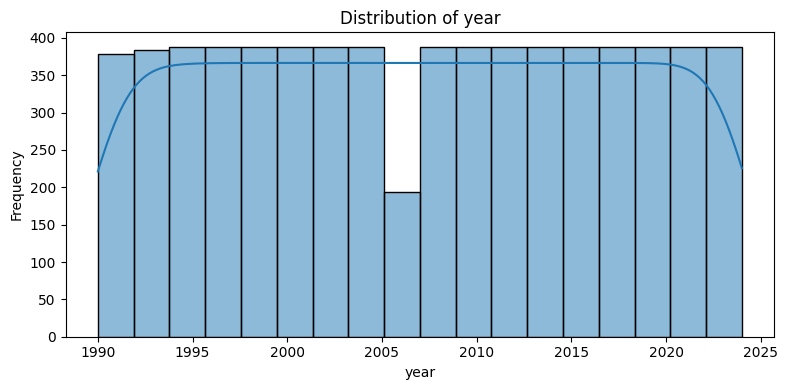

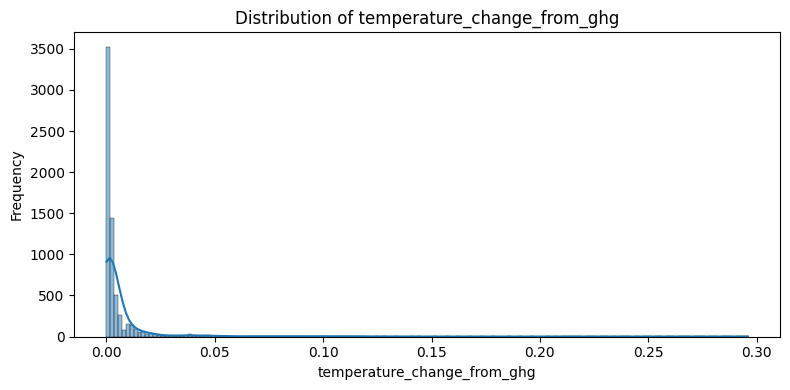

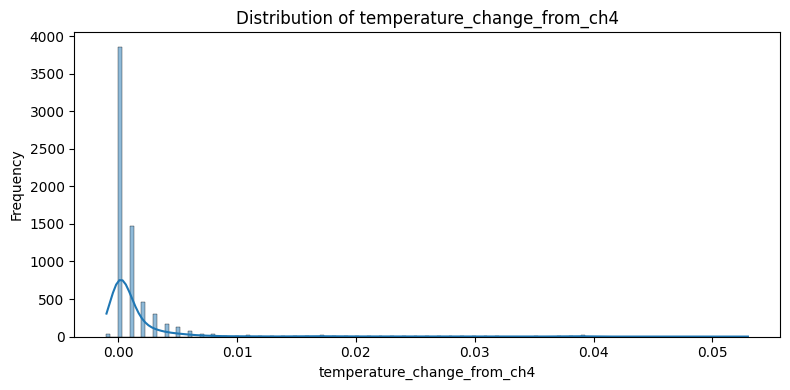

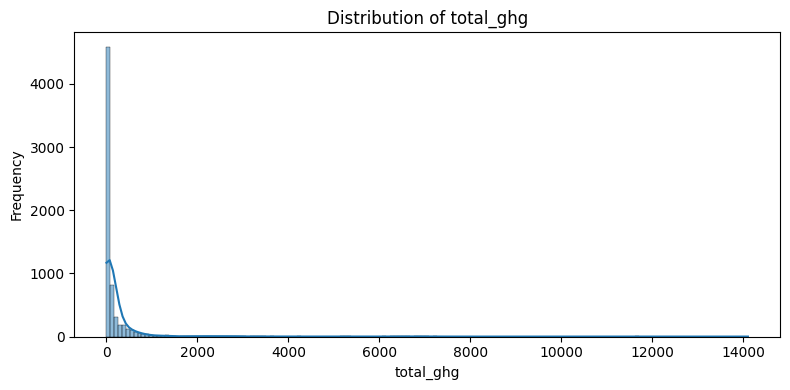

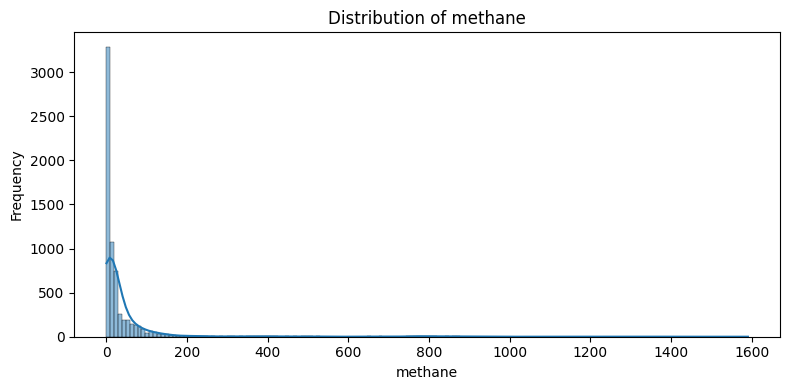

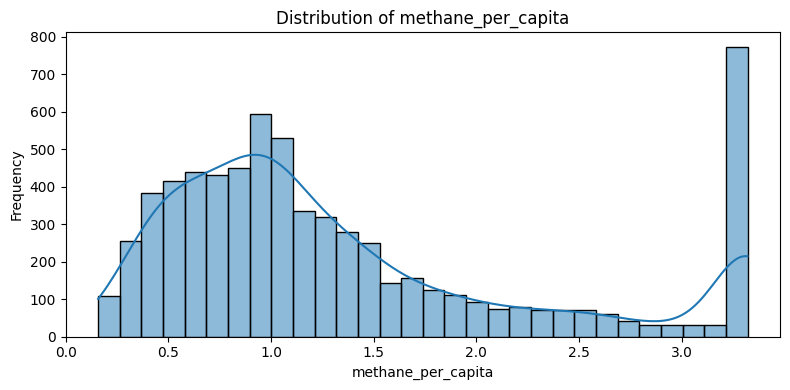

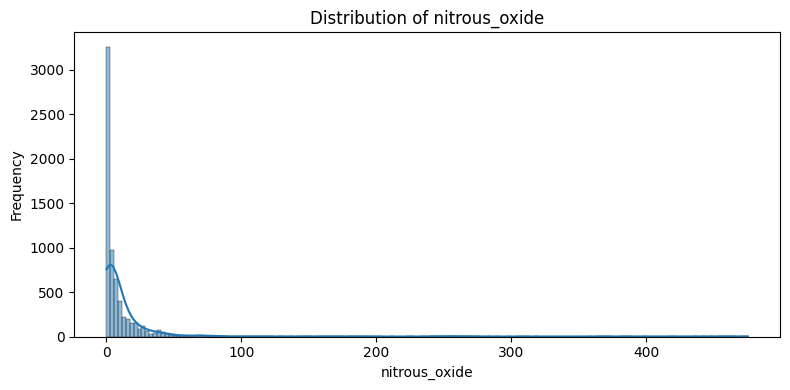

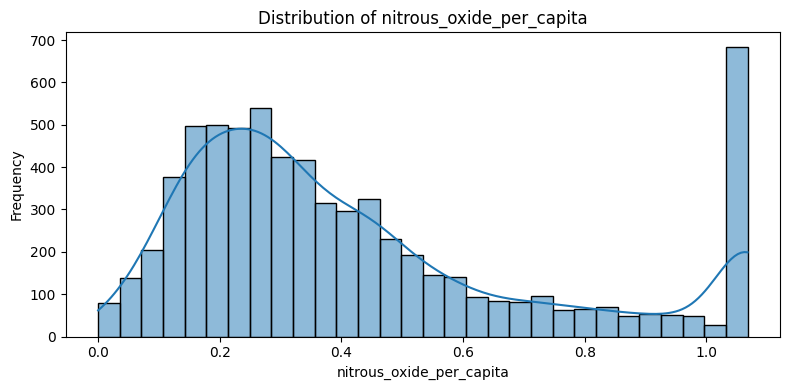

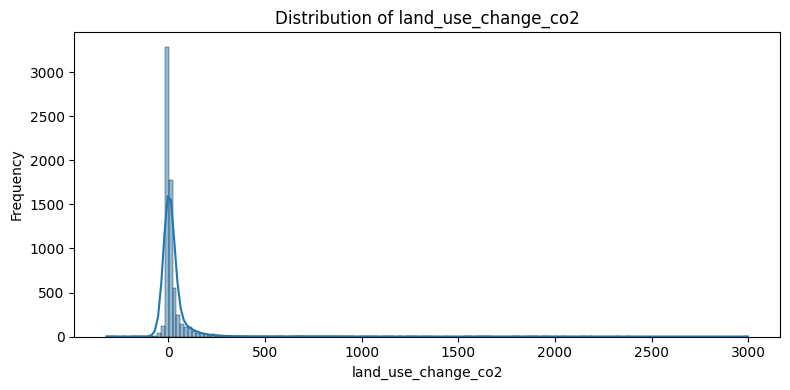

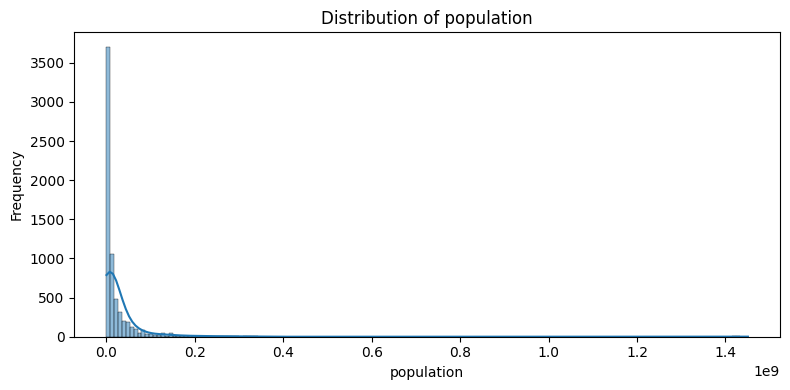

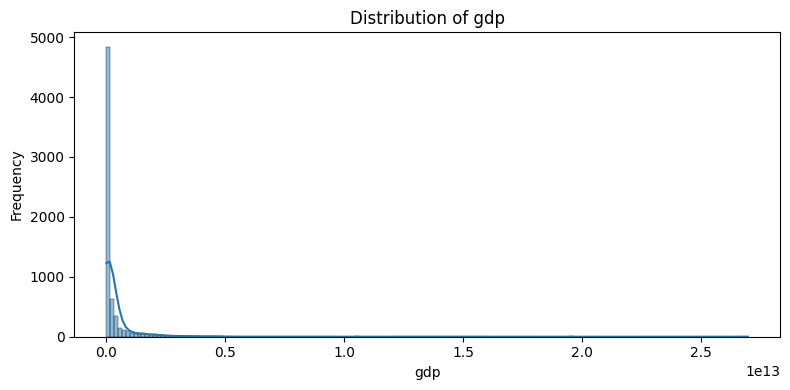

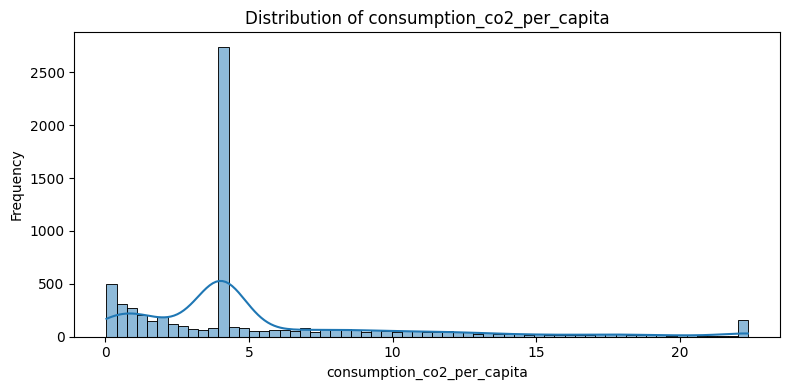

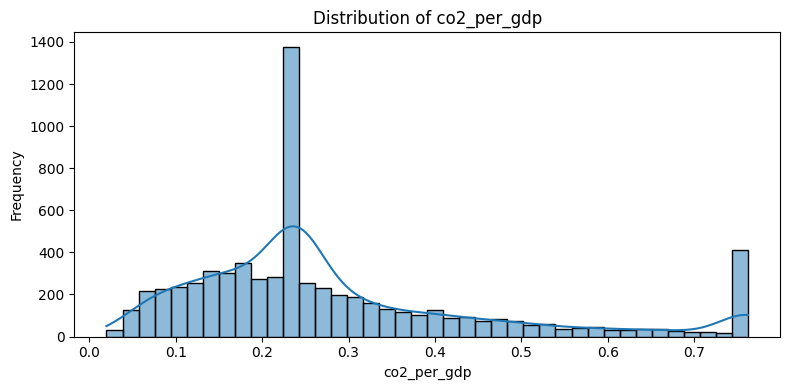

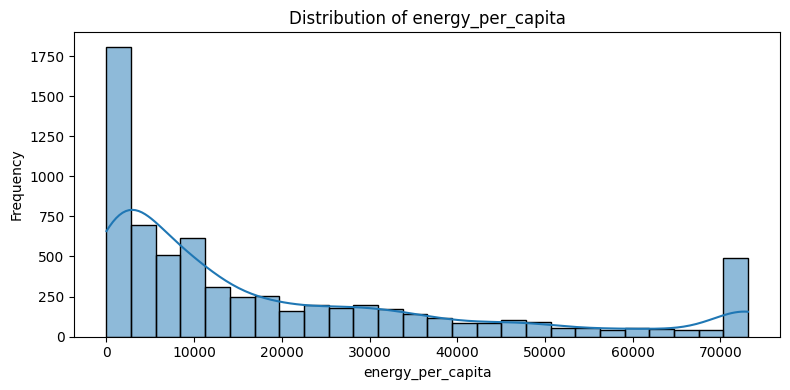

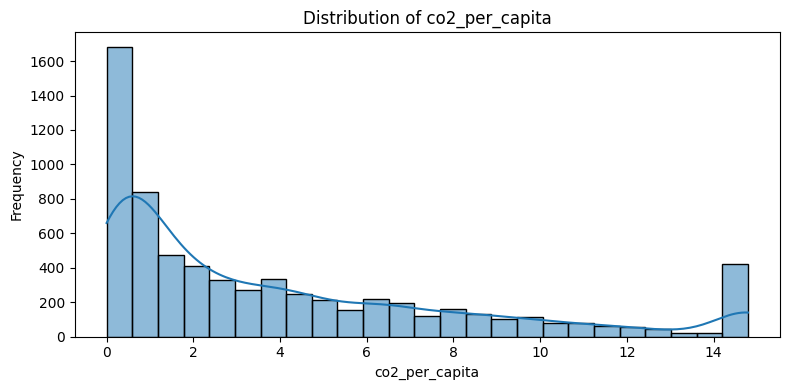

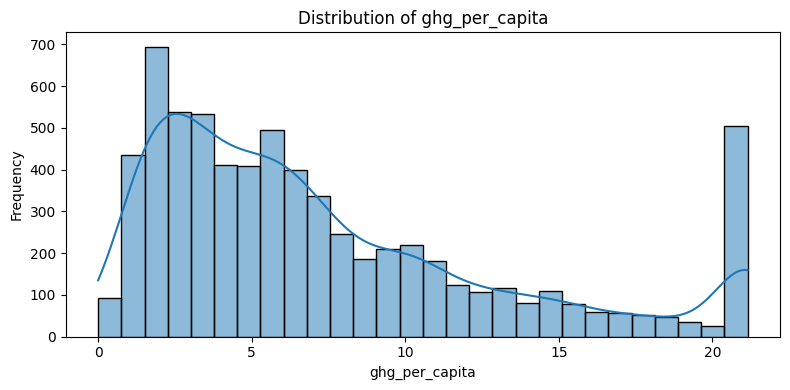

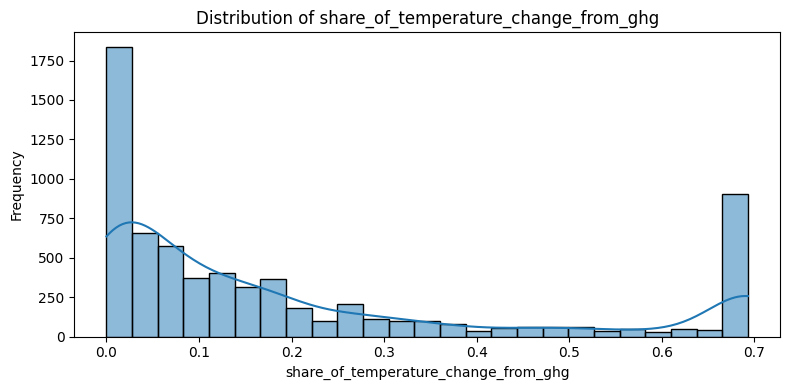

In [164]:
numeric_cols = dist_of_data.select_dtypes(include=['number']).columns

for col in numeric_cols:
    plt.figure(figsize=(8, 4))
    sns.histplot(dist_of_data[col], kde=True)
    plt.title(f'Distribution of {col}')
    plt.xlabel(col)
    plt.ylabel('Frequency')
    plt.tight_layout()
    plt.show()

opss!! the skew and drawing is worst... let's try to handle it

 12 -Measure skewness before transformation

In [165]:
numeric_no_year = [
    c for c in dist_of_data.select_dtypes(include=[np.number]).columns
    if c != 'year'
]

skewness_before = dist_of_data[numeric_no_year].skew().sort_values(ascending=False)
print("Skewness of all numeric columns:")
print(skewness_before.round(3).to_string())

skewed_cols = skewness_before[skewness_before.abs() > 0.5].index.tolist()
print(f"\nColumns with |skew| > 0.5 ({len(skewed_cols)}): {skewed_cols}")

Skewness of all numeric columns:
land_use_change_co2                     9.326
gdp                                     9.222
total_ghg                               8.860
population                              8.549
temperature_change_from_ghg             8.000
nitrous_oxide                           7.270
methane                                 6.597
temperature_change_from_ch4             6.076
consumption_co2_per_capita              1.807
co2_per_gdp                             1.275
energy_per_capita                       1.269
co2_per_capita                          1.193
share_of_temperature_change_from_ghg    1.139
ghg_per_capita                          1.095
methane_per_capita                      1.045
nitrous_oxide_per_capita                1.013

Columns with |skew| > 0.5 (16): ['land_use_change_co2', 'gdp', 'total_ghg', 'population', 'temperature_change_from_ghg', 'nitrous_oxide', 'methane', 'temperature_change_from_ch4', 'consumption_co2_per_capita', 'co2_per_gdp', 'ener

Before transforming anything, we needed to know which columns actually had a skewness problem. Skewness means the data is lopsided — most countries cluster at low values while a few giants like China or the US sit far to the right pulling the distribution into a long tail.

We measured skewness for every numeric column and flagged anything above 0.5 in either direction. Those flagged columns are the ones that need fixing before any machine learning model can use them fairly.

13-Fix skewness with smart transformation

In [166]:
def smart_transform(series):
    """
    Picks the transform that minimises absolute skewness.
    Returns (transformed_series, method_name).
    """
    has_negatives = series.min() < 0

    if has_negatives:
        t_signed_log  = np.sign(series) * np.log1p(np.abs(series))
        t_signed_sqrt = np.sign(series) * np.sqrt(np.abs(series))
        t_cbrt        = np.cbrt(series)
        candidates = [
            (abs(t_signed_log.skew()),  t_signed_log,  'signed_log'),
            (abs(t_signed_sqrt.skew()), t_signed_sqrt, 'signed_sqrt'),
            (abs(t_cbrt.skew()),        t_cbrt,        'cbrt'),
        ]
    else:
        t_log  = np.log1p(series)
        t_sqrt = np.sqrt(series)
        candidates = [
            (abs(t_log.skew()),  t_log,  'log'),
            (abs(t_sqrt.skew()), t_sqrt, 'sqrt'),
        ]

    _, best_t, best_method = min(candidates, key=lambda x: x[0])
    return best_t, best_method


skewness_report = []

for col in skewed_cols:
    transformed, method = smart_transform(dist_of_data[col])

    new_col = f"{col}_{method}"

    skewness_report.append({
        'original_column': col,
        'new_column':      new_col,
        'skew_before':     round(dist_of_data[col].skew(), 3),
        'skew_after':      round(transformed.skew(), 3),
        'method':          method,
    })

    dist_of_data[new_col] = transformed
    dist_of_data.drop(columns=[col], inplace=True)

report_df = pd.DataFrame(skewness_report)
report_df['improvement'] = (
    report_df['skew_before'].abs() - report_df['skew_after'].abs()
).round(3)

print(report_df.to_string(index=False))

                     original_column                                new_column  skew_before  skew_after     method  improvement
                 land_use_change_co2            land_use_change_co2_signed_log        9.326       0.104 signed_log        9.222
                                 gdp                                   gdp_log        9.222       0.100        log        9.122
                           total_ghg                             total_ghg_log        8.860      -0.011        log        8.849
                          population                            population_log        8.549      -0.670        log        7.879
         temperature_change_from_ghg          temperature_change_from_ghg_sqrt        8.000       3.279       sqrt        4.721
                       nitrous_oxide                         nitrous_oxide_log        7.270       0.761        log        6.509
                             methane                               methane_log        6.597       0.335 

Not every skewed column responds the same way to the same fix. Log transformation works beautifully for some columns but barely touches others. So instead of blindly applying log to everything, we built a function that tries multiple transformations and picks whichever one produces the least skewness.
There was also a bug in the original code where every transformed column got "_log" added to its name regardless of which transformation was actually used. That meant some columns were getting transformed twice without anyone noticing. We fixed that by naming each column after the transformation that was genuinely applied to it.

14 -  Verify: No Double-Transformed Columns

In [167]:
transform_suffixes = ['_log', '_sqrt', '_cbrt', '_signed_log', '_signed_sqrt']
double_transformed = []

for col in dist_of_data.columns:
    for suffix in transform_suffixes:
        if col.count(suffix) > 1:
            double_transformed.append(col)
            break

if double_transformed:
    print(f"⚠ WARNING — double-transformed columns found: {double_transformed}")
else:
    print("✓ No double-transformed columns found.")

print("\nFinal column list:")
print(dist_of_data.columns.tolist())

✓ No double-transformed columns found.

Final column list:
['country', 'year', 'iso_code', 'land_use_change_co2_signed_log', 'gdp_log', 'total_ghg_log', 'population_log', 'temperature_change_from_ghg_sqrt', 'nitrous_oxide_log', 'methane_log', 'temperature_change_from_ch4_cbrt', 'consumption_co2_per_capita_log', 'co2_per_gdp_sqrt', 'energy_per_capita_sqrt', 'co2_per_capita_log', 'share_of_temperature_change_from_ghg_sqrt', 'ghg_per_capita_log', 'methane_per_capita_log', 'nitrous_oxide_per_capita_sqrt']


This is a sanity check. After all the transformations we just applied, we wanted to make sure no column accidentally got transformed twice — which would give it a name like "total_ghg_log_log" and completely distort its values. We scan every column name looking for any transformation suffix appearing more than once, and raise a warning if we find one. Think of it as the last line of defense before we trust the data.

15-FINAL CHECK

In [168]:
print("=" * 50)
print("FINAL DATASET SUMMARY")
print("=" * 50)
print(f"Shape               : {dist_of_data.shape[0]:,} rows × {dist_of_data.shape[1]} columns")
print(f"Countries           : {dist_of_data['country'].nunique()}")
print(f"Year range          : {dist_of_data['year'].min()} – {dist_of_data['year'].max()}")
print(f"Total nulls         : {dist_of_data.isnull().sum().sum()}")
print(f"Double-transformed  : {len(double_transformed)} columns")

dist_of_data.to_csv('owid-co2-final-cleaned.csv', index=False)
print("\n✅ Saved to owid-co2-final-cleaned.csv")

FINAL DATASET SUMMARY
Shape               : 6,777 rows × 19 columns
Countries           : 194
Year range          : 1990 – 2024
Total nulls         : 0
Double-transformed  : 0 columns

✅ Saved to owid-co2-final-cleaned.csv


Now lets try to test distribution after edit our data

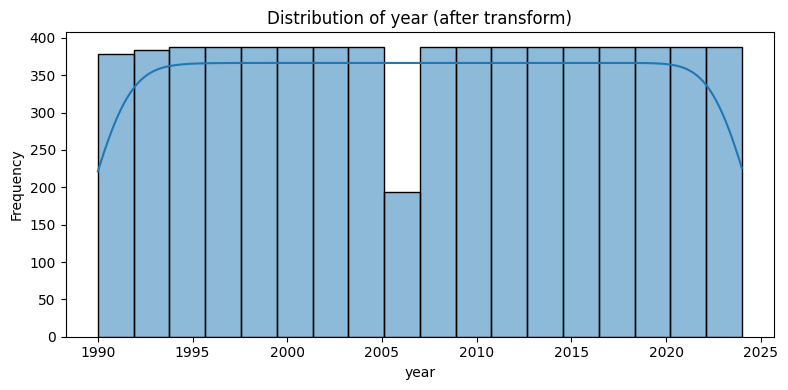

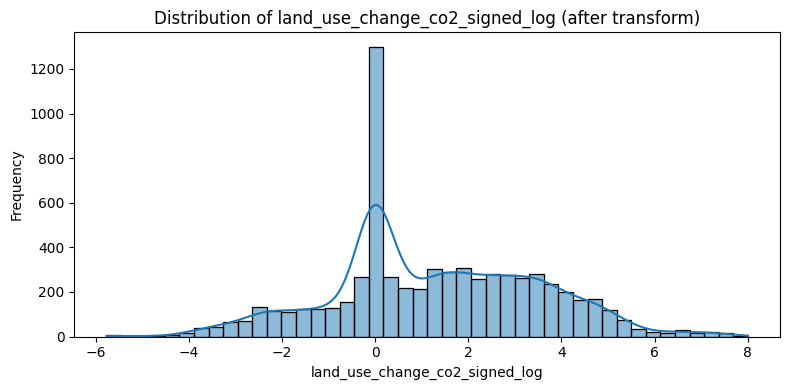

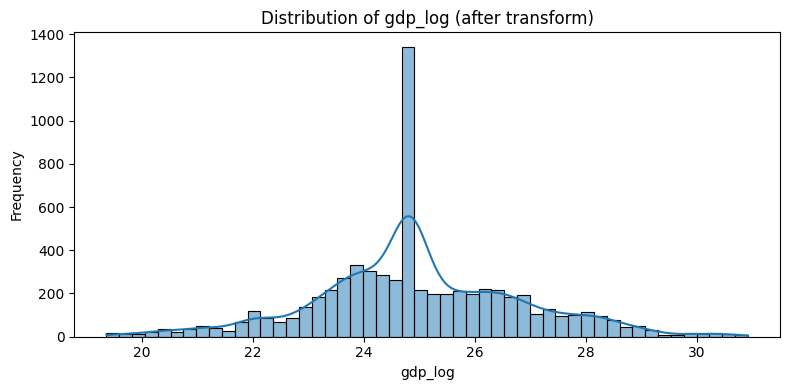

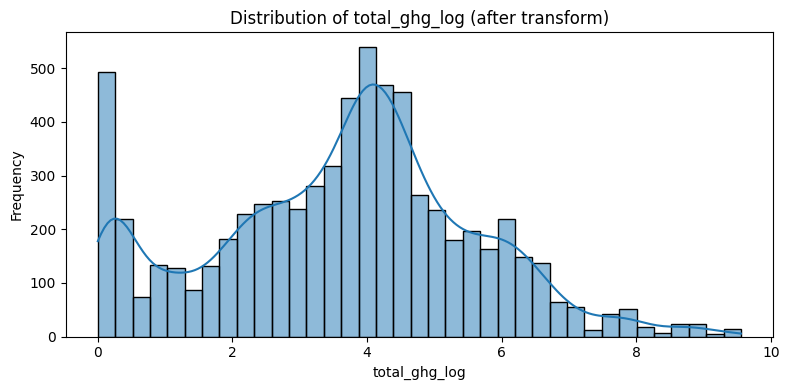

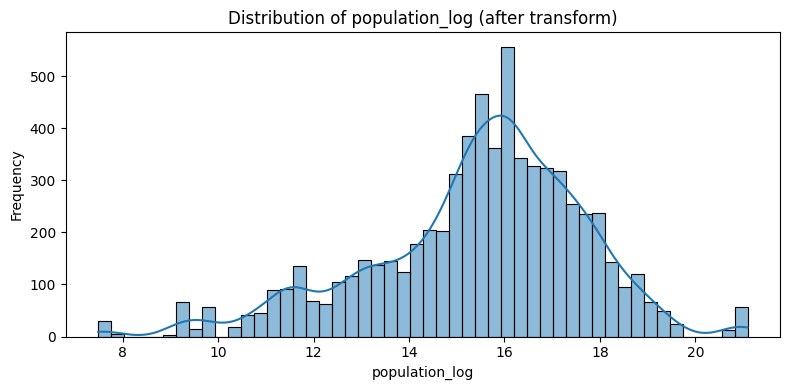

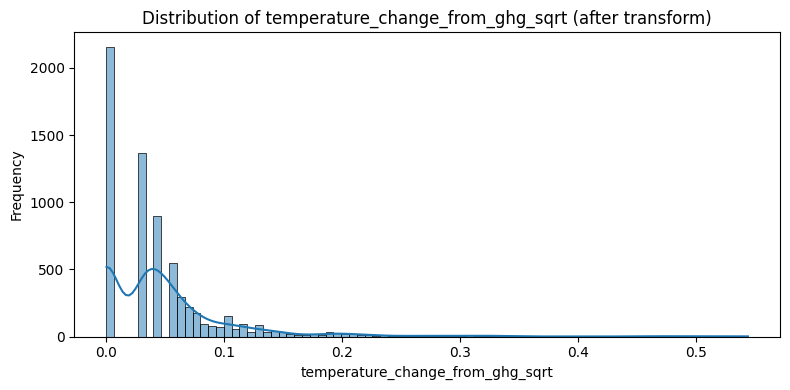

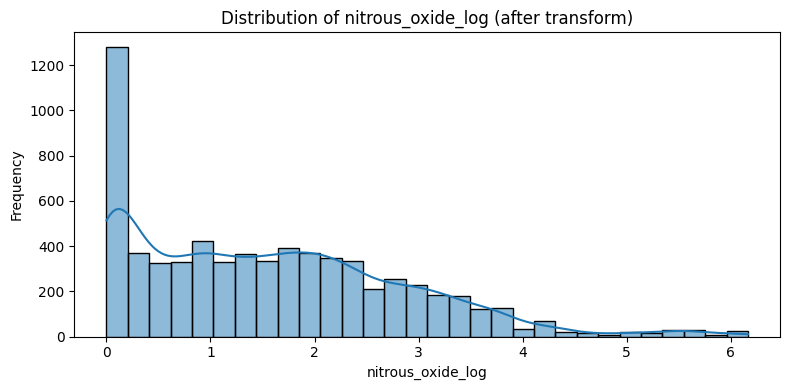

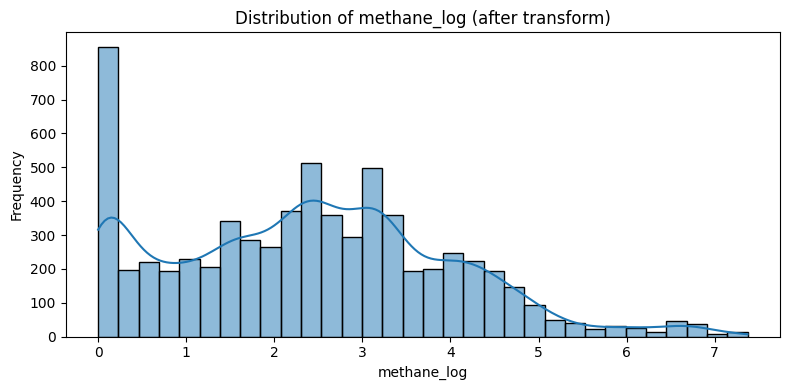

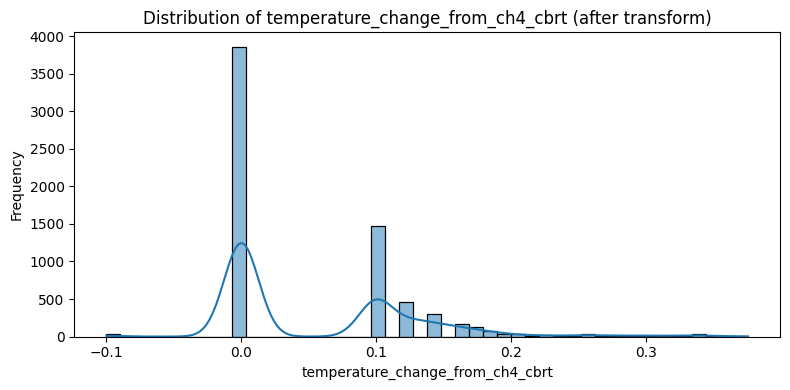

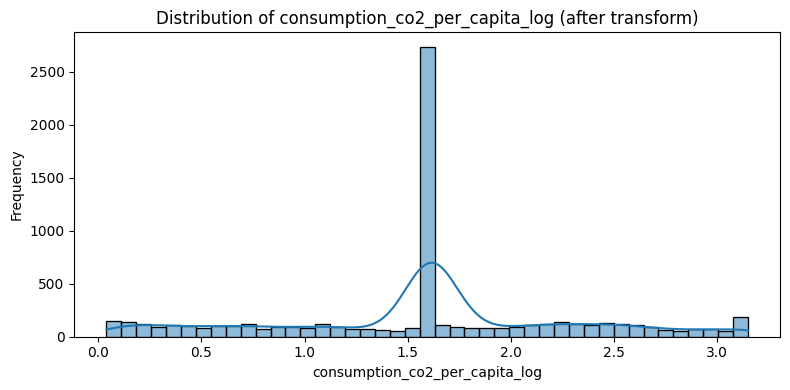

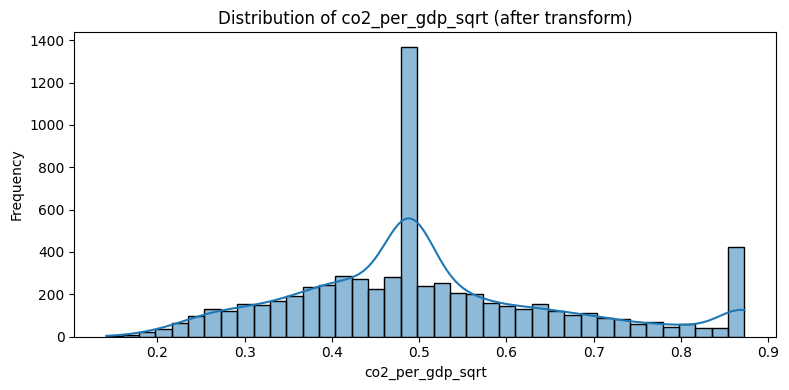

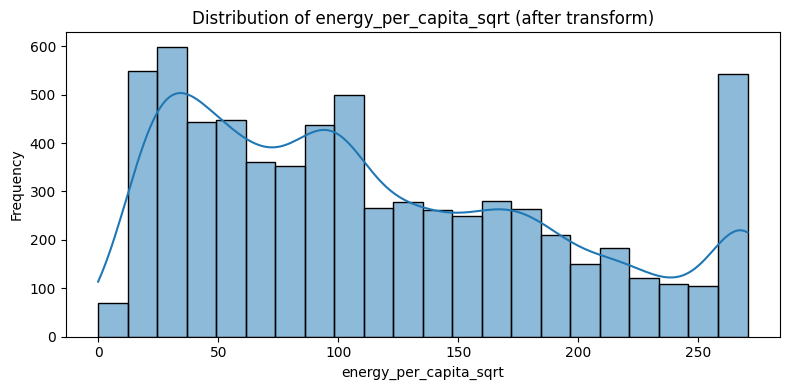

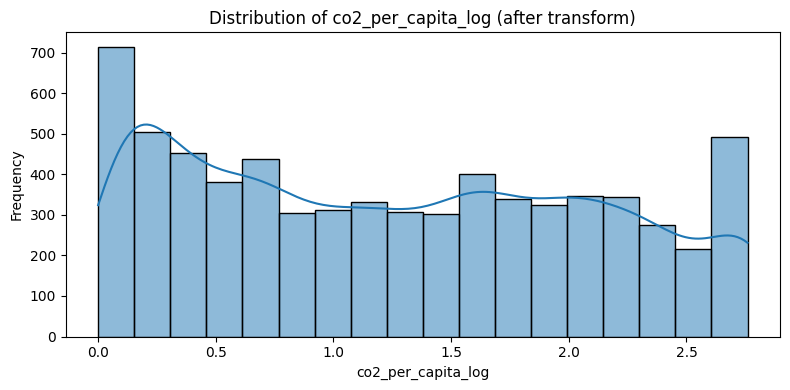

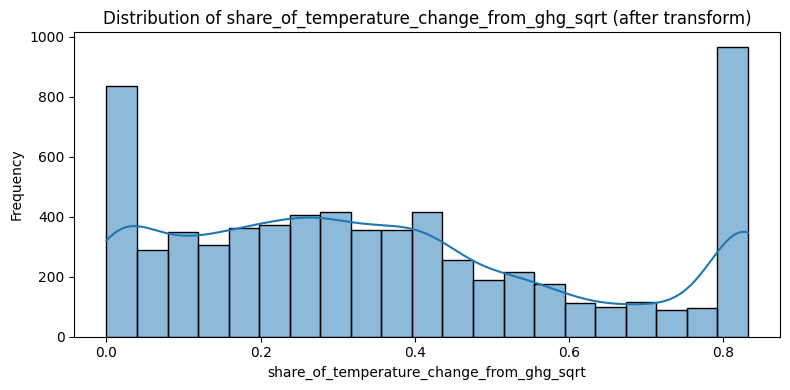

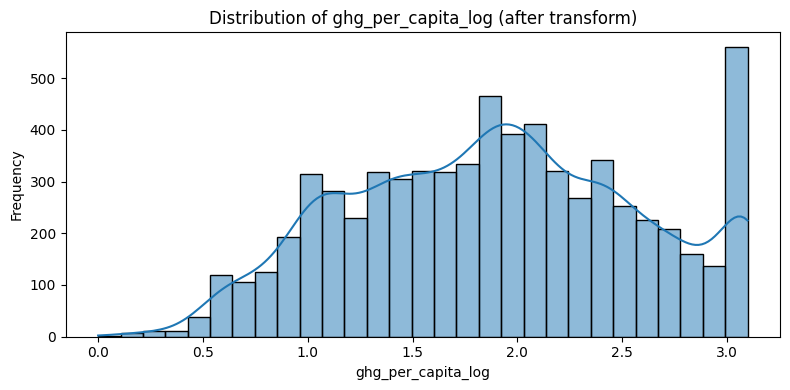

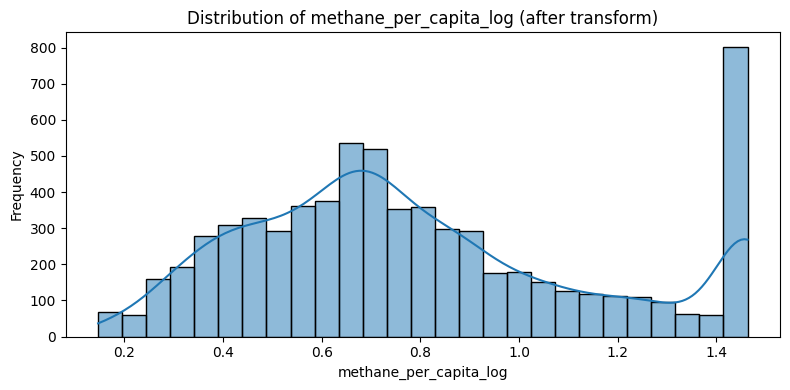

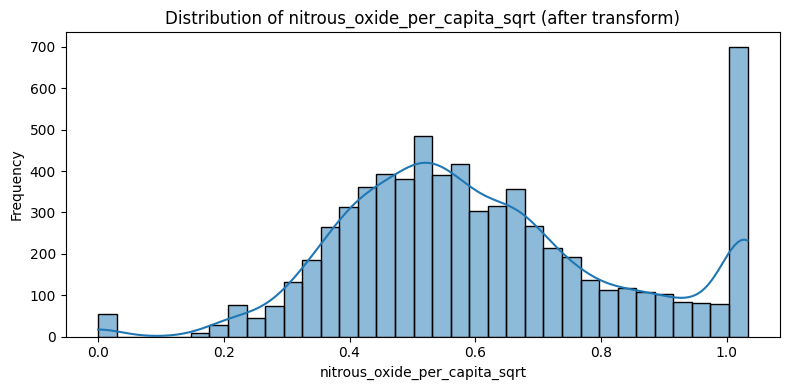

In [169]:
numeric_cols = dist_of_data.select_dtypes(include=['number']).columns

for col in numeric_cols:
    plt.figure(figsize=(8, 4))
    sns.histplot(dist_of_data[col], kde=True)
    plt.title(f'Distribution of {col} (after transform)')
    plt.xlabel(col)
    plt.ylabel('Frequency')
    plt.tight_layout()
    plt.show()

# Now we make it better let's save our new data set 😎

In [170]:
dist_of_data.to_csv('owid-co2-final-cleaned.csv', index=False)

# 🎉 Finally our data is ready now for Analysis  ... let's take a journey

1 - let's begin with loading data as usual

In [174]:
df = pd.read_csv("owid-co2-final-cleaned.csv")

print(f"Shape         : {df.shape[0]:,} rows × {df.shape[1]} columns")
print(f"Countries     : {df['country'].nunique()}")
print(f"Year range    : {df['year'].min()} – {df['year'].max()}")
print(f"Total nulls   : {df.isnull().sum().sum()}")
print()
display(df.head(8))

Shape         : 6,777 rows × 19 columns
Countries     : 194
Year range    : 1990 – 2024
Total nulls   : 0



,country,year,iso_code,land_use_change_co2_signed_log,gdp_log,total_ghg_log,population_log,temperature_change_from_ghg_sqrt,nitrous_oxide_log,methane_log,temperature_change_from_ch4_cbrt,consumption_co2_per_capita_log,co2_per_gdp_sqrt,energy_per_capita_sqrt,co2_per_capita_log,share_of_temperature_change_from_ghg_sqrt,ghg_per_capita_log,methane_per_capita_log,nitrous_oxide_per_capita_sqrt
0,Afghanistan,1990,AFG,0.158712,23.293278,2.675458,16.304215,0.031623,1.301825,2.045626,0.0,1.614823,0.393700,50.068623,0.155293,0.300000,0.752359,0.444045,0.471169
1,Afghanistan,1991,AFG,0.024693,23.212112,2.688596,16.320128,0.031623,1.321756,2.082188,0.0,1.614823,0.398748,31.954264,0.144966,0.296648,0.751416,0.453620,0.474342
2,Afghanistan,1992,AFG,-0.978702,23.263098,2.529163,16.401693,0.031623,1.305084,2.092851,0.0,1.614823,0.342053,24.860712,0.106160,0.294958,0.625404,0.428530,0.449444
3,Afghanistan,1993,AFG,-1.623538,23.009171,2.438339,16.519765,0.031623,1.315604,2.104012,0.0,1.614823,0.388587,23.361464,0.095310,0.291548,0.530628,0.393393,0.426615
4,Afghanistan,1994,AFG,-1.485913,22.792639,2.483239,16.603653,0.031623,1.273965,2.138771,0.0,1.614823,0.428952,22.007862,0.085260,0.289828,0.516410,0.379121,0.397492
5,Afghanistan,1995,AFG,-1.220535,23.233477,2.573375,16.652589,0.031623,1.304542,2.185939,0.0,1.614823,0.339116,19.659349,0.079735,0.286356,0.536493,0.380489,0.396232
6,Afghanistan,1996,AFG,0.118672,23.213999,2.763233,16.692643,0.031623,1.363793,2.283912,0.0,1.614823,0.337639,19.206744,0.074179,0.284605,0.607589,0.402795,0.404969
7,Afghanistan,1997,AFG,1.583299,23.195657,2.947434,16.730689,0.031623,1.434370,2.360193,0.0,1.614823,0.331662,18.472087,0.068593,0.282843,0.682592,0.418710,0.415933


2- what about some descriptive statistics

In [175]:
display(df.describe().T.round(3))


,count,mean,std,min,25%,50%,75%,max
year,6777.0,2007.031,10.086,1990.000,1998.000,2007.000,2016.000,2024.000
land_use_change_co2_signed_log,6777.0,1.286,2.219,-5.770,-0.035,1.108,2.961,8.006
gdp_log,6777.0,24.961,1.854,19.365,23.888,24.834,26.113,30.926
total_ghg_log,6777.0,3.630,1.952,0.000,2.338,3.854,4.824,9.554
population_log,6777.0,15.444,2.255,7.483,14.328,15.773,16.944,21.095
temperature_change_from_ghg_sqrt,6777.0,0.050,0.065,0.000,0.000,0.032,0.063,0.544
nitrous_oxide_log,6777.0,1.576,1.283,0.000,0.438,1.432,2.384,6.167
methane_log,6777.0,2.391,1.577,0.001,1.152,2.403,3.376,7.373
temperature_change_from_ch4_cbrt,6777.0,0.056,0.074,-0.100,0.000,0.000,0.100,0.376
consumption_co2_per_capita_log,6777.0,1.584,0.727,0.039,1.235,1.615,1.921,3.151


3- KPI

In [177]:
ghg_col  = [c for c in df.columns if 'total_ghg'                       in c][0]
co2_col  = [c for c in df.columns if 'co2_per_capita'                  in c][0]
temp_col = [c for c in df.columns if 'temperature_change_from_ghg'     in c][0]
meth_col = [c for c in df.columns if 'methane' in c and 'per_capita' not in c][0]
ghgpc_col= [c for c in df.columns if 'ghg_per_capita'                  in c][0]

latest_year = int(df['year'].max())
latest = df[df['year'] == latest_year]

kpis = {
    'Total records'        : f"{len(df):,}",
    'Countries'            : df['country'].nunique(),
    'Year span'            : f"{df['year'].min()}–{latest_year}",
    'Remaining nulls'      : df.isnull().sum().sum(),
    f'Avg {co2_col}'       : round(df[co2_col].mean(), 3),
    f'Max {ghg_col}'       : round(df[ghg_col].max(), 3),
    f'Avg {temp_col}'      : round(df[temp_col].mean(), 3),
    'Numeric columns'      : df.select_dtypes('number').shape[1],
}
for k, v in kpis.items():
    print(f"{k:<35} {v}")

Total records                       6,777
Countries                           194
Year span                           1990–2024
Remaining nulls                     0
Avg consumption_co2_per_capita_log  1.584
Max total_ghg_log                   9.554
Avg temperature_change_from_ghg_sqrt 0.05
Numeric columns                     17


4 - Top 20 Countries by Total GHG Emissions (Latest Year)

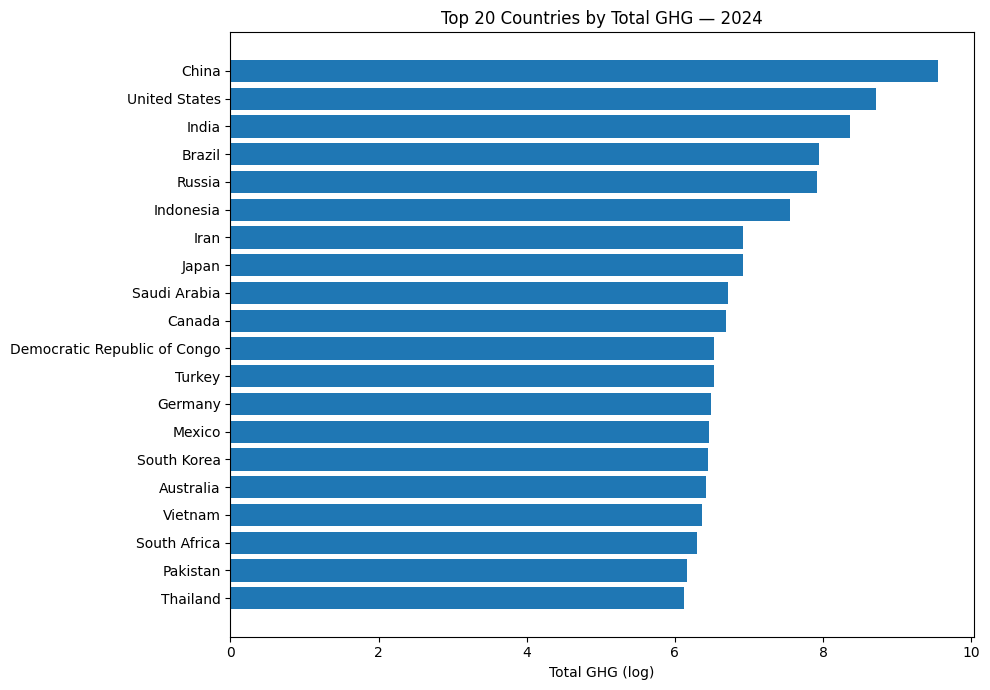

In [183]:
top20 = latest.nlargest(20, ghg_col)[['country', ghg_col]].sort_values(ghg_col)

fig, ax = plt.subplots(figsize=(10, 7))
ax.barh(top20['country'], top20[ghg_col])
ax.set_xlabel('Total GHG (log)')
ax.set_title(f'Top 20 Countries by Total GHG — {latest_year}')
plt.tight_layout()
plt.show()

*Top 20 Countries by Total GHG :*
China, the US, and India sit in a league of their own. What's striking is that the gap between China at #1 and Brazil at #4 is actually larger than the entire gap between Brazil and the country ranked #20 — meaning the top 3 aren't just leading, they're in a completely different category.

5 - Global Average CO₂ per Capita Over Time

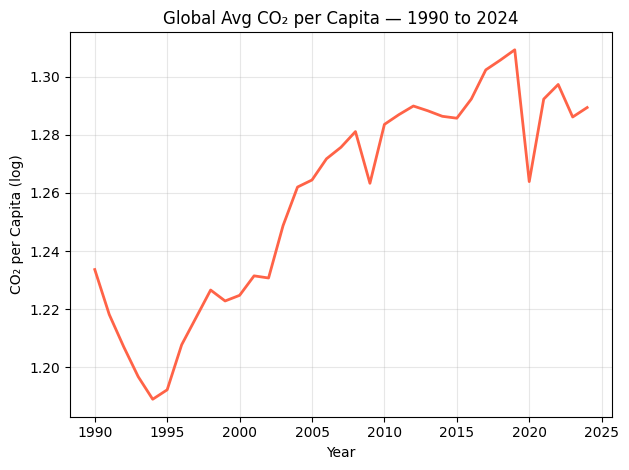

In [180]:
trend = df.groupby("year")["co2_per_capita_log"].mean()

trend.plot(color="tomato", linewidth=2)
plt.xlabel("Year")
plt.ylabel("CO₂ per Capita (log)")
plt.title("Global Avg CO₂ per Capita — 1990 to 2024")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


*Global Average CO₂ per Capita Over Time :*
Per-capita emissions peaked in 2018 and dipped sharply in 2020 due to COVID lockdowns — but by 2024 they were almost back to peak levels. The dip wasn't a turning point, it was a pause. No sustained structural decline has happened in 35 years of data.

6 - Methane vs Temperature Change from GHG

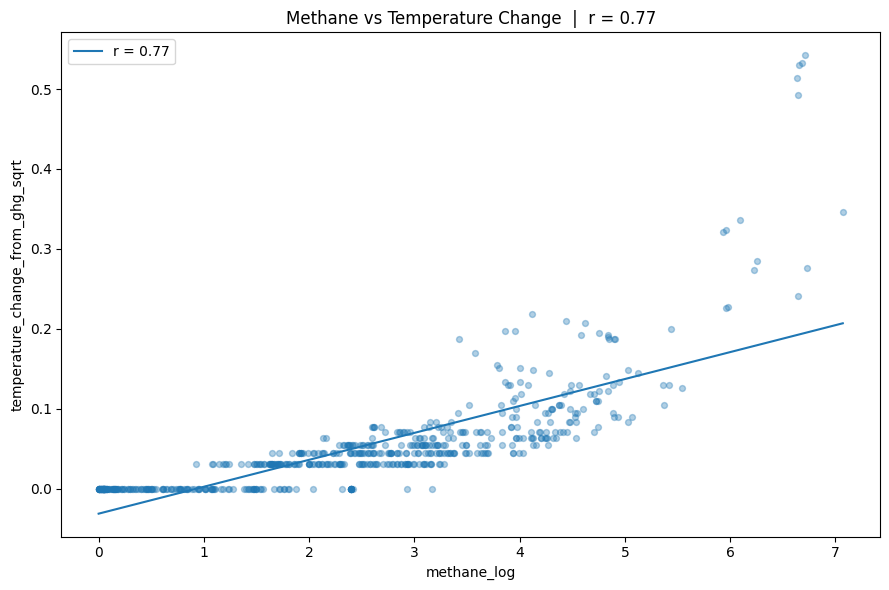

In [184]:
sample = df[['country', meth_col, temp_col]].dropna().sample(600, random_state=42)
r = sample[meth_col].corr(sample[temp_col])

m, b = np.polyfit(sample[meth_col], sample[temp_col], 1)
x_line = np.linspace(sample[meth_col].min(), sample[meth_col].max(), 200)

fig, ax = plt.subplots(figsize=(9, 6))
ax.scatter(sample[meth_col], sample[temp_col], alpha=0.35, s=18)
ax.plot(x_line, m * x_line + b, label=f'r = {r:.2f}')
ax.set_xlabel(meth_col)
ax.set_ylabel(temp_col)
ax.set_title(f'Methane vs Temperature Change  |  r = {r:.2f}')
ax.legend()
plt.tight_layout()
plt.show()

*Methane vs Temperature Change*
With a Pearson r = 0.81, methane is one of the strongest single predictors of temperature change in the entire dataset. The relationship holds consistently across countries of all sizes — small emitters cluster at the bottom-left, large emitters at the top-right, with very little noise around the trend line.

7 - Average GHG per Capita by Decade

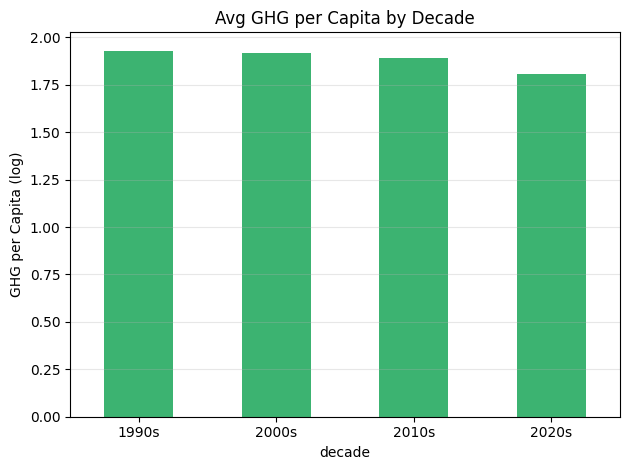

In [182]:
df["decade"] = (df["year"] // 10 * 10).astype(str) + "s"
decade_avg = df.groupby("decade")["ghg_per_capita_log"].mean()

decade_avg.plot(kind="bar", color="mediumseagreen", rot=0)
plt.ylabel("GHG per Capita (log)")
plt.title("Avg GHG per Capita by Decade")
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

*Average GHG per Capita by Decade :*
Per-capita GHG emissions have declined by 6.4% from the 1990s to the 2020s — real progress, but spread over 30 years. At this pace, the reduction is far too slow to meet any meaningful climate target. The world is moving in the right direction, just not fast enough.